# Evaluation of the Binding Sites Prediction model
Compares the predicted residues by the Random Forest model with the real residues in the binding site (PDBbind) for 15 proteins not seen duraning training, randomly selected.

**Inputs per protein:**
- `{pdb_id}_pocket.pdb` → real residues in the binding site (PDBbind).
- `{pdb_id}_protein_binding_site_residues.txt` → predicted residues by the model.

**Outputs:**
- Metrics per protein: Accuracy, Precision, Recall, F1, ROC-AUC, MCC
- Aggregated Global metrics 
- Global Confusion matrix 

## 0. Imports

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from Bio.PDB import PDBParser
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, ConfusionMatrixDisplay)

FOLDER_POCKETS   = "pockets/"         
FOLDER_PREDICTED = "predictions/"   
FOLDER_PROTEINS  = "proteins/"        

# List of the PDB IDs to evaluate
PDB_IDS = ['2y7x', '2y82', '3qs4', '3qzt', '3rf5', '3s1h', '4awi', '4c1g', '4ehg', '4x6i', '4zam', '5al4', '5e7n', '5fqb', '5jm4']

print(f"Proteins to be evaluated: {len(PDB_IDS)}")

Proteins to be evaluated: 15


## 1. Parsing functions

In [8]:
def parsing_pocket_pdb(pocket_pdb_path):
    """
    Reads a _pocket.pdb file from PDBbind and returns a set of tuples (chain_id, res_seq) with the real residues of the binding site.
    """
    resid_real = set()
    with open(pocket_pdb_path, 'r') as f:
        for line in f:
            if line.startswith('ATOM'):
                chain  = line[21].strip()        # col. 22
                res_id = int(line[22:26].strip()) # col. 23-26
                resid_real.add((chain, res_id))
    return resid_real


def parsing_predicted_txt(predichos_txt_path):
    """
    Reads a _binding_site_residues.txt file generated by inference.py and returns a set of tuples (chain_id, res_seq).
    """
    resid_predicted = set()
    with open(predichos_txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            if (not line or line.startswith('Binding') or
                line.startswith('Total') or line.startswith('=') or
                line.startswith('-') or line.startswith('Chain')): 
                continue
            parts = line.split()
            if len(parts) >= 2:
                chain  = parts[0]
                res_id = int(parts[1])
                resid_predicted.add((chain, res_id))
    return resid_predicted


def obtain_all_residues(protein_pdb_path):
    """
    Reads the complete protein and returns the set with all its residues (chain, res_id).
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", protein_pdb_path)
    all_res = set()
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.get_id()[0] == ' ':  # only ATOM
                    all_res.add((chain.get_id(), residue.get_id()[1]))
    return all_res


print("Parsing functions defined.")

Parsing functions defined.


## 2. Metrics function per protein

In [9]:
def calculate_metrics(reals, predicts, all_residues):
    """
    Builds y_true / y_pred vectors for each residue and computes their metrics, by using the real residues, predictes residues and all residues sets.
    """
    y_true = []
    y_pred = []

    for residuo in all_residues:
        y_true.append(1 if residuo in reals    else 0)
        y_pred.append(1 if residuo in predicts else 0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'pr_auc':    average_precision_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'n_reals':    int(len(reals)),
        'n_predicts': int(len(predicts)),
        'n_total':     int(len(all_residues)),
    }
    return metrics, y_true, y_pred


print("Metrics function defined.")

Metrics function defined.


## 3. Evaluation of the independent set of proteins

In [15]:
results     = []   
y_true_global  = []   
y_pred_global  = []
errors        = []   

for pdb_id in PDB_IDS:
    pocket_path  = os.path.join(FOLDER_POCKETS,   f"{pdb_id}_pocket.pdb")
    pred_path    = os.path.join(FOLDER_PREDICTED, f"{pdb_id}_protein_binding_site_residues.txt")
    protein_path = os.path.join(FOLDER_PROTEINS,  f"{pdb_id}_protein.pdb")

    # Verifying the 3 files exist
    faltan = [p for p in [pocket_path, pred_path, protein_path] if not os.path.exists(p)]
    if faltan:
        print(f"[SKIP] {pdb_id}: missing file → {faltan}")
        errors.append(pdb_id)
        continue

    try:
        reals          = parsing_pocket_pdb(pocket_path)
        predicts       = parsing_predicted_txt(pred_path)
        all_residues  = obtain_all_residues(protein_path)

        metrics, y_t, y_p = calculate_metrics(reals, predicts, all_residues)
        metrics['pdb_id'] = pdb_id
        results.append(metrics)

        y_true_global.extend(y_t)
        y_pred_global.extend(y_p)

        print(f"[OK] {pdb_id:8s} | Real: {metrics['n_reals']:4d} | "
              f"Predicted: {metrics['n_predicts']:4d} | "
              f"Recall: {metrics['recall']:.3f} | "
              f"Precision: {metrics['precision']:.3f} | "
              f"MCC: {metrics['mcc']:.3f}")

    except Exception as e:
        print(f"[ERROR] {pdb_id}: {e}")
        errors.append(pdb_id)

print(f"\nProcesed proteins: {len(results)} / {len(PDB_IDS)}")
if errors:
    print(f"With errors: {errors}")

[OK] 2y7x     | Real:   80 | Predicted:  125 | Recall: 0.475 | Precision: 0.304 | MCC: 0.038
[OK] 2y82     | Real:   79 | Predicted:  135 | Recall: 0.570 | Precision: 0.333 | MCC: 0.112
[OK] 3qs4     | Real:   94 | Predicted:  165 | Recall: 0.628 | Precision: 0.358 | MCC: 0.308
[OK] 3qzt     | Real:   55 | Predicted:   47 | Recall: 0.473 | Precision: 0.553 | MCC: 0.077
[OK] 3rf5     | Real:   66 | Predicted:  125 | Recall: 0.455 | Precision: 0.240 | MCC: 0.096
[OK] 3s1h     | Real:   78 | Predicted:  147 | Recall: 0.692 | Precision: 0.367 | MCC: 0.237
[OK] 4awi     | Real:   79 | Predicted:  153 | Recall: 0.696 | Precision: 0.359 | MCC: 0.288
[OK] 4c1g     | Real:   58 | Predicted:   90 | Recall: 0.569 | Precision: 0.367 | MCC: 0.193
[OK] 4ehg     | Real:  100 | Predicted:  234 | Recall: 0.640 | Precision: 0.274 | MCC: 0.196
[OK] 4x6i     | Real:   62 | Predicted:  105 | Recall: 0.516 | Precision: 0.305 | MCC: 0.035
[OK] 4zam     | Real:   79 | Predicted:  104 | Recall: 0.468 | Precisi

## 4. Table of results per protein

In [16]:
df_res = pd.DataFrame(results).set_index('pdb_id')

cols_display = ['n_reals', 'n_predicts', 'TP', 'FP', 'FN', 'TN', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']

df_display = df_res[cols_display].copy()

metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']
df_display[metrics_cols] = df_display[metrics_cols].round(3)

print("Results for each protein:")
display(df_display)

Results for each protein:


,n_reals,n_predicts,TP,FP,FN,TN,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
pdb_id,,,,,,,,,,,,,
2y7x,80,125,38,87,42,114,0.541,0.304,0.475,0.371,0.038,0.521,0.294
2y82,79,135,45,90,34,112,0.559,0.333,0.570,0.421,0.112,0.562,0.311
3qs4,94,165,59,106,35,307,0.722,0.358,0.628,0.456,0.308,0.686,0.293
3qzt,55,47,26,21,29,32,0.537,0.553,0.473,0.510,0.077,0.538,0.530
3rf5,66,125,30,95,36,187,0.624,0.240,0.455,0.314,0.096,0.559,0.213
3s1h,78,147,54,93,24,127,0.607,0.367,0.692,0.480,0.237,0.635,0.335
4awi,79,153,55,98,24,180,0.658,0.359,0.696,0.474,0.288,0.672,0.317
4c1g,58,90,33,57,25,104,0.626,0.367,0.569,0.446,0.193,0.607,0.323
4ehg,100,234,64,170,36,266,0.616,0.274,0.640,0.383,0.196,0.625,0.242


## 5. Agreggated Global Metrics

In [17]:
y_true_global = np.array(y_true_global)
y_pred_global = np.array(y_pred_global)

print("="*50)
print("GLOBAL METRICS (all proteins)")
print("="*50)
print(f"Total number of evaluated residues : {len(y_true_global):,}")
print(f"Total number of real positives : {y_true_global.sum():,}")
print(f"Total number of predicted positives: {y_pred_global.sum():,}")
print()
print(classification_report(y_true_global, y_pred_global, target_names=['No binding (0)', 'Binding (1)']))

mcc_global = matthews_corrcoef(y_true_global, y_pred_global)
roc_global = roc_auc_score(y_true_global, y_pred_global)
pr_global  = average_precision_score(y_true_global, y_pred_global)

print(f"MCC global   : {mcc_global:.4f}")
print(f"ROC-AUC global: {roc_global:.4f}")
print(f"PR-AUC global : {pr_global:.4f}")

GLOBAL METRICS (all proteins)
Total number of evaluated residues : 4,635
Total number of real positives : 1,129
Total number of predicted positives: 1,935

                precision    recall  f1-score   support

No binding (0)       0.82      0.63      0.71      3506
   Binding (1)       0.33      0.57      0.42      1129

      accuracy                           0.62      4635
     macro avg       0.58      0.60      0.57      4635
  weighted avg       0.70      0.62      0.64      4635

MCC global   : 0.1770
ROC-AUC global: 0.6017
PR-AUC global : 0.2949


## 6. Global Confussion Matrix

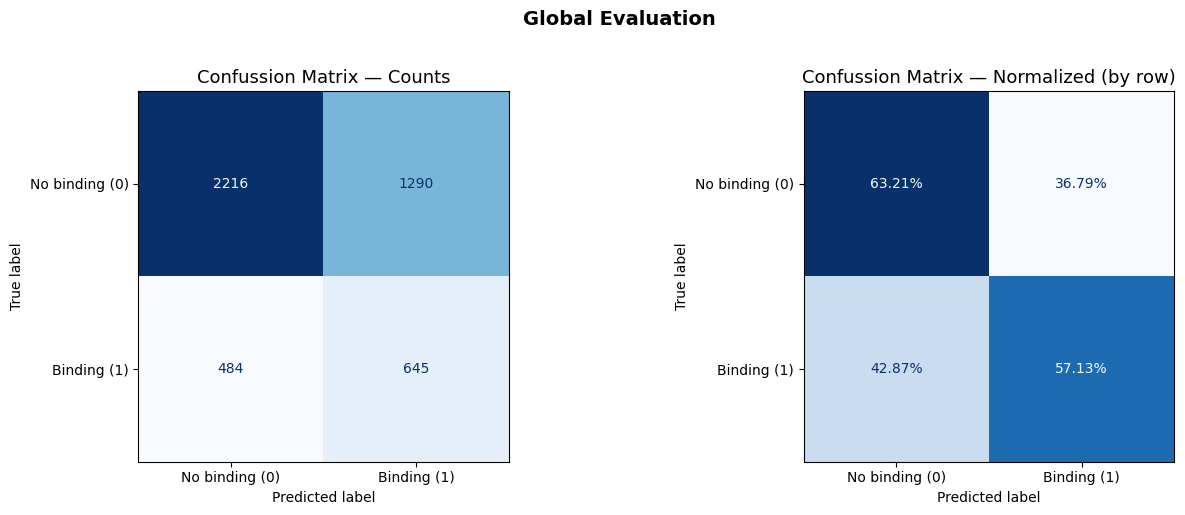

TP=645  FP=1,290  FN=484  TN=2,216


In [18]:
cm_global = confusion_matrix(y_true_global, y_pred_global, labels=[0, 1])
tn, fp, fn, tp = cm_global.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_global,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_counts.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confussion Matrix — Counts', fontsize=13)

# Percentages (normalized by row)
cm_norm = cm_global.astype(float) / cm_global.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Confussion Matrix — Normalized (by row)', fontsize=13)

plt.suptitle('Global Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")

## 7. Save results to CSV

In [19]:
df_res.to_csv('evaluation_results.csv')
print("Results saved in: evaluation_results.csv")

# Summary
print("\n" + "="*50)
print("BINDING SUMMARY")
print("="*50)
print(f"Proteins evaluated : {len(df_res)}")
print(f"Average Recall        : {df_res['recall'].mean():.3f} ± {df_res['recall'].std():.3f}")
print(f"Average Precision     : {df_res['precision'].mean():.3f} ± {df_res['precision'].std():.3f}")
print(f"Average F1            : {df_res['f1'].mean():.3f} ± {df_res['f1'].std():.3f}")
print(f"Average MCC           : {df_res['mcc'].mean():.3f} ± {df_res['mcc'].std():.3f}")
print(f"Global ROC-AUC        : {roc_global:.4f}")
print(f"Global PR-AUC         : {pr_global:.4f}")

Results saved in: evaluation_results.csv

BINDING SUMMARY
Proteins evaluated : 15
Average Recall        : 0.567 ± 0.094
Average Precision     : 0.354 ± 0.082
Average F1            : 0.429 ± 0.062
Average MCC           : 0.162 ± 0.096
Global ROC-AUC        : 0.6017
Global PR-AUC         : 0.2949
